<a href="https://colab.research.google.com/github/pd-25/ML-algorithm-implements/blob/main/naive_bayes/spam_sms_naive_byes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [52]:
df = pd.read_csv('spam.csv',encoding='latin-1')


In [53]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4167,spam,Congrats! Nokia 3650 video camera phone is you...,NaN,NaN,NaN
4702,ham,Mmmmmmm *snuggles into you* ...*deep contented...,NaN,NaN,NaN
3229,ham,I feel like a dick because I keep sleeping thr...,NaN,NaN,NaN
3691,ham,No i am not having not any movies in my laptop,NaN,NaN,NaN
1259,ham,We have sent JD for Customer Service cum Accou...,NaN,NaN,NaN


In [54]:
df.shape

(5572, 5)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [57]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)


KeyError: "['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'] not found in axis"

In [58]:
df.sample(5)

,v1,v2
3943,ham,"Until 545 lor... Ya, can go 4 dinner together..."
537,ham,Or maybe my fat fingers just press all these b...
4936,ham,G wants to know where the fuck you are
706,ham,So when do you wanna gym harri
5159,ham,No but the bluray player can


In [59]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)

In [60]:
df.sample(5)

,target,text
5350,ham,No one interested. May be some business plan.
3638,ham,Wat's da model num of ur phone?
910,ham,My love ! How come it took you so long to leav...
2873,ham,Crucify is c not s. You should have told me ea...
3500,ham,says the &lt;#&gt; year old with a man and m...


In [61]:
#If there are messy data like 'hum', ' hum ', 'HUm' then use this below
# df['target_col'] = df['target_col'].str.strip().str.lower().map({'yes': True, 'no': False})

# df['target'].value_counts()
#as we check suing value_count, the data is only 2 type and clean so we use pandas labelencoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [62]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [63]:
df.isnull().sum()

,0
target,0
text,0


In [64]:
df.duplicated().sum()

np.int64(403)

In [65]:
df.drop_duplicates(keep="first", inplace=True)

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df['target'].value_counts()

,count
target,
0,4516
1,653


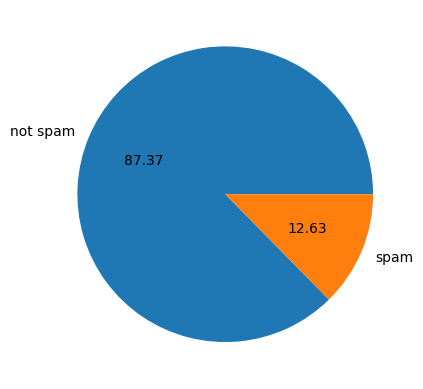

In [68]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['not spam', 'spam'], autopct="%0.2f")
plt.show()

In [79]:
#As we get data is imbalanced
#lets create few more column for better performance

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [80]:
df['num_characters'] = df['text'].apply(len)

In [81]:
df.sample(5)

,target,text,num_characters
5366,1,A å£400 XMAS REWARD IS WAITING FOR YOU! Our co...,157
2375,0,Thanx 4 2day! U r a goodmate I THINK UR RITE S...,95
3543,0,Lol ok ill try to send. Be warned Sprint is de...,84
4052,0,I was slept that time.you there?,32
146,1,FreeMsg Why haven't you replied to my text? I'...,159


In [83]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [84]:
df.head(5)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [85]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [86]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
